Columnas finales: ['credit_score', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn', 'country_Germany', 'country_Spain']
[[1460  133]
 [ 162  245]]
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1593
           1       0.65      0.60      0.62       407

    accuracy                           0.85      2000
   macro avg       0.77      0.76      0.77      2000
weighted avg       0.85      0.85      0.85      2000

CV AUC-ROC: 0.8614 ± 0.0056
CV Accuracy : 0.8507 ± 0.0077
CV F1  : 0.8482 ± 0.0079


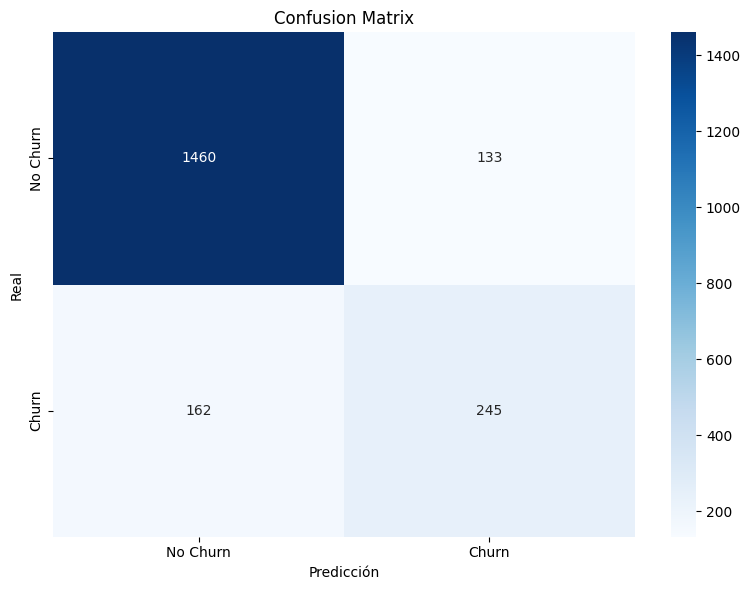

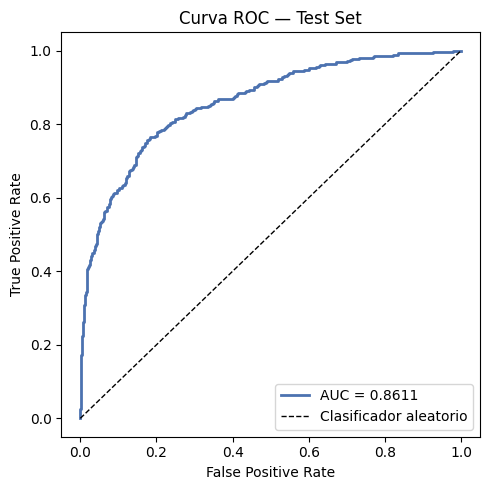


--- 7.1 Importancia global de características ---


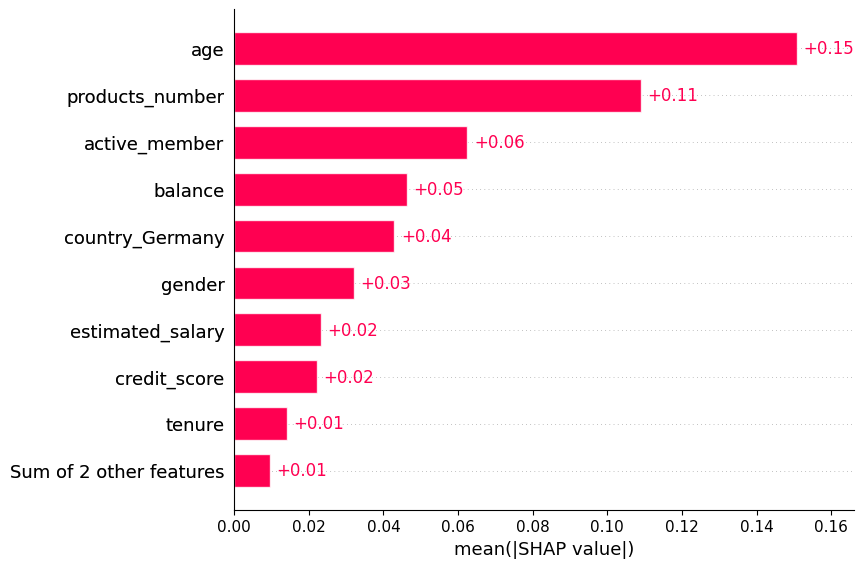


--- 7.2 Distribución y dirección de efectos (beeswarm) ---


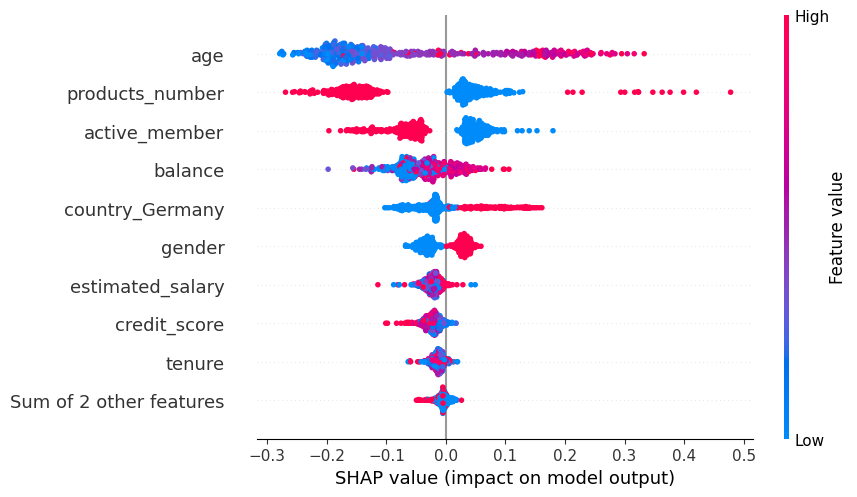


--- 7.3 Explicación del primer paciente (waterfall) ---


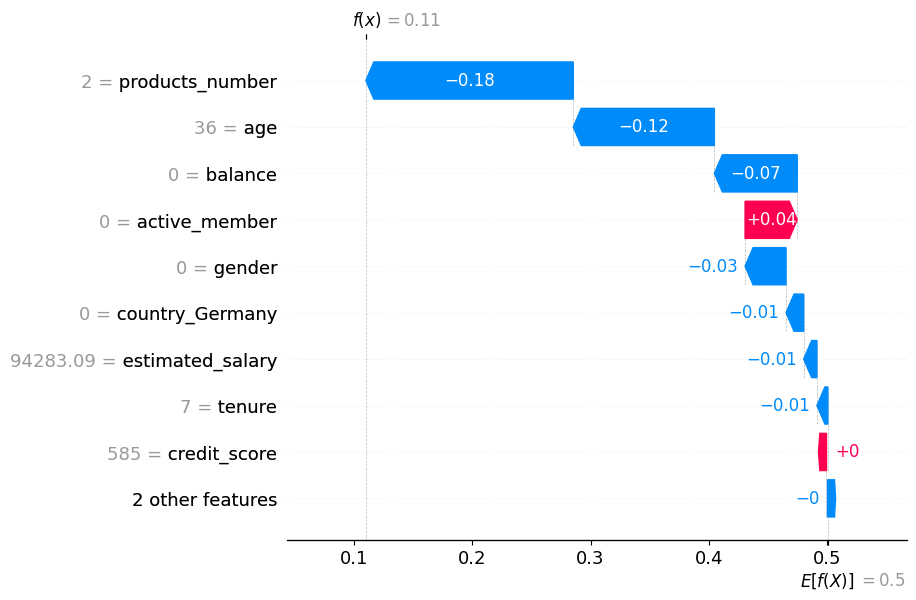


--- 7.4 Heatmap de efectos en todo el subconjunto ---


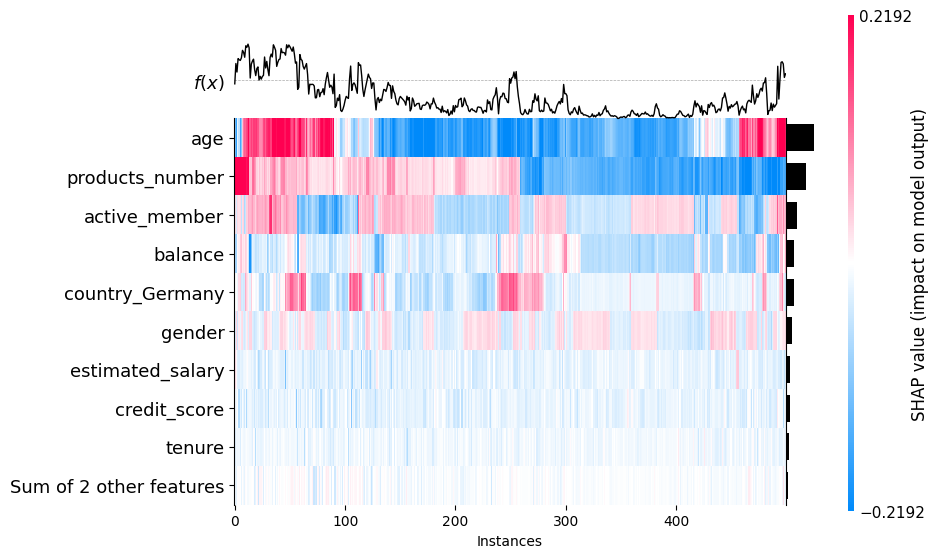

<Axes: xlabel='Instances'>

In [16]:
import os
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc

# ── Carga de datos
df = pd.read_csv("Bank Customer Churn Prediction.csv")
df = df.drop(columns=["customer_id"], errors='ignore') # Elimina la columna/s que no se necesitan

# Convierte el texto de la columna 'gender' por numeros (0 para Male y 1 para Female)
df["gender"] = df["gender"].map({"Male": 0, "Female": 1})
df = pd.get_dummies(df, columns=["country"], drop_first=True, dtype=int)
print("Columnas finales:", df.columns.tolist())

# ── Split
# stratify=y garantiza que cada split mantenga la proporción de clases original
X = df.drop("churn", axis=1)
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

modelo.fit(X_train, y_train) # entrena con el 80% de los datos
pred = modelo.predict(X_test) # predice sobre el 20% restante (datos no vistos)
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

# Validación cruzada con 5 folds para medir estabilidad del mode
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc = cross_val_score(modelo, X, y, cv=cv, scoring="accuracy")
f1 = cross_val_score(modelo, X, y, cv=cv, scoring="f1_weighted")
auc_cv = cross_val_score(modelo, X, y, cv=cv, scoring="roc_auc")
print(f"CV AUC-ROC: {auc_cv.mean():.4f} ± {auc_cv.std():.4f}")
print(f"CV Accuracy : {acc.mean():.4f} ± {acc.std():.4f}")
print(f"CV F1  : {f1.mean():.4f} ± {f1.std():.4f}")

# ── Confusion Matrix
# Muestra cuántas predicciones acertó y falló el modelo por cada categoría
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
ax.set_title("Confusion Matrix")
ax.set_ylabel("Real")
ax.set_xlabel("Predicción")
plt.tight_layout()
plt.show()
plt.close("all")

# ──── Grafica Curva Roc
# Evalúa qué tan bien separa el modelo las dos clases (infarto vs no infarto)
proba_scores = modelo.predict_proba(X_test)[:, 1] # Probabilidad de pertenecer a la clase positiva (infarto=1)
fpr, tpr, _ = roc_curve(y_test, proba_scores) # FPR = falsas alarmas, TPR = aciertos reales
roc_auc = auc(fpr, tpr) # AUC cercano a 1.0 = modelo casi perfecto; 0.5 = aleatorio

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="#4C72B0", lw=2, label=f"AUC = {roc_auc:.4f}") # Curva del modelo
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador aleatorio") # Línea base de referencia (sin poder predictivo)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curva ROC — Test Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()
plt.close("all")

# ──── Graficas con Shap
# Cuantifica cuánto contribuye cada variable a la predicción del modelo.
X_sample = X_test[:500].copy()
explainer = shap.TreeExplainer(modelo) # Explainer optimizado para modelos basados en árboles (XGBoost, LightGBM, etc.)
shap_values = explainer(X_sample) # Calcula el valor SHAP de cada feature para cada paciente del subconjunto

# Selecciona solo los SHAP values de la clase positiva (churn=1)
shap_values_class1 = shap_values[..., 1]

print("\n--- 7.1 Importancia global de características ---")
shap.plots.bar(shap_values_class1, max_display=10)

print("\n--- 7.2 Distribución y dirección de efectos (beeswarm) ---")
shap.plots.beeswarm(shap_values_class1, max_display=10)

print("\n--- 7.3 Explicación del primer churn (waterfall) ---")
shap.plots.waterfall(shap_values_class1[0], max_display=10)

print("\n--- 7.4 Heatmap de efectos en todo el subconjunto ---")
shap.plots.heatmap(shap_values_class1)